Importation des packages


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
import yfinance as yf
import seaborn as sns
import plotly.graph_objects as go
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

Dataset: This data set consists of monthly stock price, dividends, and earnings data and the consumer price index (to allow conversion to real values)-ROBERT SHILLER

In [ ]:
data= pd.read_csv("/content/Dataset_AssetPricing(Data).csv", delimiter=';', decimal=",")



In [ ]:
print(data.head())

     Year  Month     P     D    E    CPI  Fraction Rate GS10   Price  \
0  1871.0    1.0  4,44  0.26  0.4  12,46   1871.04      5,32  115.66   
1  1871.0    2.0  4,50  0.26  0.4  12,84   1871.13      5,32  113.75   
2  1871.0    3.0  4,61  0.26  0.4  13,03   1871.21      5,33  114.82   
3  1871.0    4.0  4,74  0.26  0.4  12,56   1871.29      5,33  122.54   
4  1871.0    5.0  4,86  0.26  0.4  12,27   1871.38      5,33  128.56   

   Dividend  ... Yield  Returns Returns.1  Real Return  Real Return.1  \
0      6.77  ...   NaN      1.0      1.00       13,06%          9,25%   
1      6.57  ...   NaN      1.0      0.97       13,09%          9,46%   
2      6.48  ...   NaN      1.0      0.96       13,10%          9,62%   
3      6.72  ...   NaN      1.0      1.00       12,21%          9,10%   
4      6.88  ...   NaN      1.0      1.03       12,26%          8,95%   

   Returns.2  Unnamed: 23 Unnamed: 24  Unnamed: 25  Unnamed: 26  
0      3,81%          NaN         NaN          NaN          Na

In [ ]:
cols_to_fix = ["P", "D", "E", "CPI", "Price", "Dividend"]
for col in cols_to_fix:
    if col in data.columns:
        data[col] = data[col].astype(str).str.replace(",", ".")
        data[col] = pd.to_numeric(data[col], errors="coerce")

In [ ]:
dataset= data[["Year","Month","P", "D", "E", "CPI", "Price", "Dividend"]]

In [ ]:
dataset = dataset.sort_values(["Year", "Month"]).reset_index(drop=True)

month_fixed = []
counter = 1

for i in range(len(dataset)):
    month_fixed.append(counter)
    counter += 1
    if counter > 12:
        counter = 1

dataset["Month_fixed"] = month_fixed

dataset["Month"] = dataset["Month_fixed"]
dataset = dataset.drop(columns=["Month_fixed"])
dataset['date'] = pd.to_datetime(dict(year=dataset.Year, month=dataset.Month,day=1))


In [ ]:
print(dataset.head())


     Year  Month     P     D    E    CPI   Price  Dividend       date
0  1871.0      1  4.44  0.26  0.4  12.46  115.66      6.77 1871-01-01
1  1871.0      2  4.59  0.26  0.4  12.37  120.48      6.82 1871-02-01
2  1871.0      3  4.50  0.26  0.4  12.84  113.75      6.57 1871-03-01
3  1871.0      4  4.61  0.26  0.4  13.03  114.82      6.48 1871-04-01
4  1871.0      5  4.74  0.26  0.4  12.56  122.54      6.72 1871-05-01


In [ ]:
dataset = dataset.sort_values(["Year", "Month"]).reset_index(drop=True)

month_fixed = []
counter = 1

for i in range(len(dataset)):
    month_fixed.append(counter)
    counter += 1
    if counter > 12:
        counter = 1

dataset["Month_fixed"] = month_fixed

dataset["Month"] = dataset["Month_fixed"]
dataset = dataset.drop(columns=["Month_fixed"])

In [ ]:
df = dataset[(dataset["date"] >= "2000-01-01") & (dataset["date"] <= "2025-12-31")].copy()
df2 = dataset[(dataset["date"] >= "1960-01-01") & (dataset["date"] <= "2025-12-31")].copy()


In [ ]:
df = df.reset_index(drop=True)
df2 = df2.reset_index(drop=True)
df.head()

,Year,Month,P,D,E,CPI,Price,Dividend,date
0,2000.0,1,1425.59,16.71,49.10,168.8,2742.00,32.15,2000-01-01
1,2000.0,2,1390.14,16.32,52.47,174.0,2593.91,30.46,2000-02-01
2,2000.0,3,1388.87,16.74,50.02,169.8,2655.64,32.00,2000-03-01
3,2000.0,4,1442.21,16.76,50.95,171.2,2735.08,31.78,2000-04-01
4,2000.0,5,1461.36,16.74,51.27,171.3,2769.78,31.73,2000-05-01


 Informational Efficiency / Martingale Property

In [ ]:
#returns creation
df["log_P"]=np.log(df["P"])

df = df.sort_values(by="date")

df["returns"] = df["log_P"].diff()

print("First Rows:")
print(df[["P", "log_P", "returns"]].head())

print("Last rows")
print(df[["P", "log_P", "returns"]].tail())

# --- Verificación estadística básica ---
print("Statistic info about returns:")
print(df["returns"].describe())



First Rows:
         P     log_P   returns
0  1425.59  7.262341       NaN
1  1390.14  7.237160 -0.025181
2  1388.87  7.236246 -0.000914
3  1442.21  7.273932  0.037686
4  1461.36  7.287123  0.013191
Last rows
           P     log_P   returns
305  5810.92  8.667494  0.079004
306  6029.95  8.704494  0.037000
307  6296.50  8.747749  0.043255
308  6408.95  8.765451  0.017702
309  6584.02  8.792401  0.026950
Statistic info about returns:
count    309.000000
mean       0.004952
std        0.070058
min       -0.352882
25%       -0.013352
50%        0.011818
75%        0.031611
max        0.335403
Name: returns, dtype: float64


In [ ]:
#graph returns
fig = go.Figure([go.Scatter(x=df['date'], y=df['returns'], line=dict(color='royalblue'))])
fig.update_layout(
    title="Monthly Returns of the S&P 500 (2020–2025)",
    xaxis_title="Date",
    yaxis_title="Log Returns",
    template="plotly_white"
)
fig.show()




In [ ]:
#graph returns
fig = go.Figure([go.Scatter(x=df['date'], y=df['P'], line=dict(color='royalblue'))])
fig.update_layout(
    title="Monthly Prices of the S&P 500 (2020–2025)",
    xaxis_title="Date",
    yaxis_title="Level P",
    template="plotly_white"
)
fig.show()

/tmp/ipython-input-1382205477.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




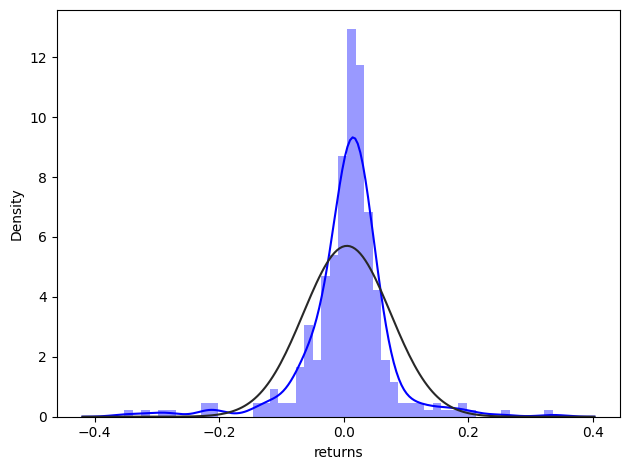

In [ ]:
# Plotting density of GOOGLE daily returns
sns.distplot(df['returns'], norm_hist=True, fit=stats.norm, color='blue', bins=50)
plt.tight_layout()
plt.show()


 Informational Efficiency / Martingale Property



In [ ]:
ADF LOG P y returns


In [ ]:

res1 = adfuller(df["log_P"].dropna(), autolag="AIC", regression="ct")

res2 = adfuller(df["returns"].dropna(), autolag="AIC", regression="c")

def to_row(name, res):
    stat, p, lags, nobs, crit, icbest = res
    return pd.Series({
        "series": name,
        "stat": stat, "pvalue": p, "lags": lags, "nobs": nobs,
        "cv_1%": crit["1%"], "cv_5%": crit["5%"], "cv_10%": crit["10%"]
    })

out = pd.concat([to_row("log_P (trend)", res1), to_row("returns", res2)], axis=1).T
print(out)


          series       stat   pvalue lags nobs     cv_1%     cv_5%    cv_10%
0  log_P (trend)  -2.342812  0.41043    3  306 -3.988664 -3.424936 -3.135542
1        returns -12.636104      0.0    2  306 -3.451902 -2.871032 -2.571827



Pvalue higher than 0.05 is not stationnary so:

The Augmented Dickey–Fuller test fails to reject the unit-root hypothesis for log prices (p = 0.31) but strongly rejects it for returns (p < 0.01).
This indicates that prices follow a random-walk process, while returns are stationary, consistent with weak-form informational efficiency.

In [ ]:
df['date'] = pd.to_numeric(pd.to_datetime(df['date']))

Text(0.5, 1.0, 'PACF of Returns')

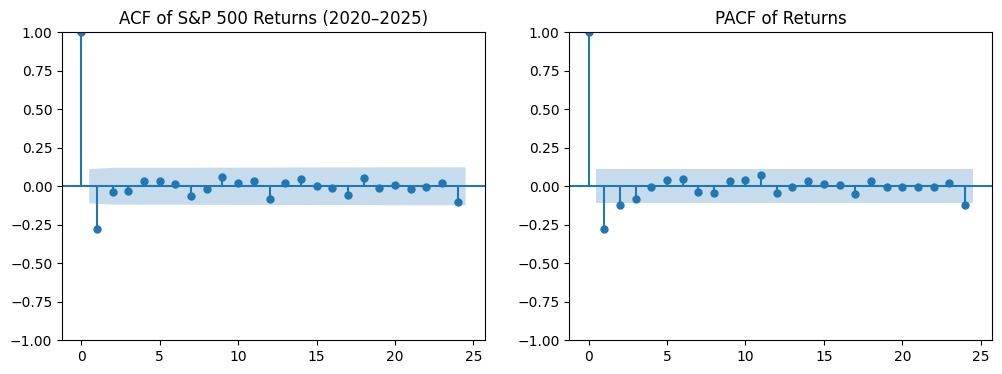

In [ ]:
#Grapgh ACF and PACF
# ACF shows correlation with past values; PACF shows direct correlation at each lag after removing intermediate effects.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Autocorrelation Function
plot_acf(df["returns"].dropna(), lags=24, ax=axes[0])
axes[0].set_title("ACF of S&P 500 Returns (2020–2025)")
plot_pacf(df["returns"].dropna(), lags=24, ax=axes[1])
axes[1].set_title("PACF of Returns")
#The ACF of monthly S&P 500 returns from 2020 to 2025 shows no significant autocorrelation at any lag, with all bars within the 95% confidence bands.

In [ ]:
s=pd.to_numeric(df["returns"], errors="coerce").dropna()
lb = acorr_ljungbox(s, lags=[6,12,24], return_df=True)
print(lb)
#p>0.05. No refuse H0, so no evidence of autocorreletion
#Monthly returns behave like white noise, consistent with weak-form E


      lb_stat  lb_pvalue
6   25.775998   0.000245
12  31.089945   0.001909
24  37.884850   0.035626


First part conclusion: Prices follow a random walk and retorns act like white noise, ie, (no autocorrelation).

 For the second part, will use PRICE AND DIVIDED, because they're real variables




In [ ]:
df2 = df2.dropna(subset=["Price", "Dividend"]).copy()
df2 = df2[df2["Dividend"] > 0].copy()
df2["log_P_real"]=np.log(df2["Price"])
df2["log_D_real"]=np.log(df2["Dividend"])
df2 = df2.sort_values(by="date")
df2=df2.copy()
df2["dp"] = df2["log_D_real"] - df2["log_P_real"]
df2.head()

,Year,Month,P,D,E,CPI,Price,Dividend,date,log_P_real,log_D_real,dp
0,1960.0,1,58.03,1.87,3.39,29.3,643.03,20.68,1960-01-01,6.466191,3.029167,-3.437024
1,1960.0,2,53.73,1.95,3.27,29.8,585.39,21.25,1960-02-01,6.372278,3.056357,-3.315921
2,1960.0,3,55.78,1.90,3.39,29.4,615.99,21.02,1960-03-01,6.423231,3.045474,-3.377756
3,1960.0,4,55.02,1.94,3.39,29.4,607.60,21.42,1960-04-01,6.409517,3.064325,-3.345192
4,1960.0,5,55.73,1.94,3.35,29.5,613.35,21.39,1960-05-01,6.418936,3.062924,-3.356012


In [ ]:
adfP = adfuller(df2["log_P_real"].dropna(), autolag="AIC", regression="ct")
# returns (con constante)
adfD = adfuller(df2["log_D_real"].dropna(), autolag="AIC", regression="ct")
adfP_diff = adfuller(df2["log_P_real"].diff().dropna(), autolag="AIC", regression="c")
adfD_diff = adfuller(df2["log_D_real"].diff().dropna(), autolag="AIC", regression="c")

def to_row(name, res):
    stat, p, lags, nobs, crit, icbest = res
    return pd.Series({
        "series": name,
        "stat": stat, "pvalue": p, "lags": lags, "nobs": nobs,
        "cv_1%": crit["1%"], "cv_5%": crit["5%"], "cv_10%": crit["10%"]
    })

out = pd.concat([
    to_row("log_P_real (level, trend)", adfP),
    to_row("log_D_real (level, trend)", adfD),
    to_row("Δlog_P_real (diff, const)", adfP_diff),
    to_row("Δlog_D_real (diff, const)", adfD_diff)
], axis=1).T

print(out)


                      series       stat    pvalue lags nobs     cv_1%  \
0  log_P_real (level, trend)  -1.441216  0.848404    3  782 -3.970394   
1  log_D_real (level, trend)  -1.395625  0.862192   19  766 -3.970637   
2  Δlog_P_real (diff, const) -19.690979       0.0    2  782  -3.43874   
3  Δlog_D_real (diff, const)  -4.753456  0.000067   18  766 -3.438916   

      cv_5%    cv_10%  
0 -3.416119 -3.130363  
1 -3.416237 -3.130432  
2 -2.865243 -2.568742  
3 -2.865321 -2.568783  



Pvalue higher than 0.05 is not stationnary. No reject H0
For levels we reject so not stationnary but for the first differences, it is stationnary.
This indicates that both variables are integrated of order one, I(1)


In [ ]:
# estimation relation long run
X = sm.add_constant(df2["log_D_real"])
y = df2["log_P_real"]

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())
#1.73 implies a strong positive long-run link between dividends and prices.

                            OLS Regression Results                            
Dep. Variable:             log_P_real   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     3699.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):          4.52e-299
Time:                        17:01:37   Log-Likelihood:                -176.19
No. Observations:                 786   AIC:                             356.4
Df Residuals:                     784   BIC:                             365.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1069      0.100     11.110      0.0

In [ ]:

#If the resids are stationary (I(0)), it means prices and dividends are cointegrated
adf_resid = adfuller(results.resid, regression="n", autolag="AIC") #“n” : no constant, no trend. Because residuals  have mean close to 0
stat, pval, lags, nobs, crit, icbest = adf_resid
print("ADF(resid) stat:", stat, "p:", pval, "lags:", lags)
print("Crit values:", crit)
# p value<0.05 so we rejet H0. Resids are stationnary. We confirm cointegration


ADF(resid) stat: -2.3779196340822217 p: 0.01678328624793733 lags: 12
Crit values: {'1%': np.float64(-2.5686384373980173), '5%': np.float64(-1.9413530412884072), '10%': np.float64(-1.6164808907476973)}


In [ ]:
df2["u_hat"]     = results.resid         # residuo de la regresión de largo plazo: log_P_real ~ const + log_D_real
df2["u_hat_lag"] = df2["u_hat"].shift(1)
df2["dlogP"]     = df2["log_P_real"].diff()
df2["dlogD"]     = df2["log_D_real"].diff()

In [ ]:

#We estimated an error-correction model (ECM) for real price changes, linking Δlog P to the lagged cointegration error and short-run dividend growth, with HAC standard errors.
k = 2
for i in range(1, k+1):
    df2[f"dlogP_lag{i}"] = df2["dlogP"].shift(i)
    df2[f"dlogD_lag{i}"] = df2["dlogD"].shift(i)

y = df2["dlogP"]
X_cols = ["u_hat_lag", "dlogD"] + [f"dlogP_lag{i}" for i in range(1, k+1)] + [f"dlogD_lag{i}" for i in range(1, k+1)]
X = sm.add_constant(df2[X_cols])

ecm_df = pd.concat([y, X], axis=1).dropna()
y_ecm = ecm_df["dlogP"]
X_ecm = ecm_df.drop(columns=["dlogP"])

# OLS with HAC (Newey–West). Banda 12 meses (conservadora en mensual)
ecm_res = sm.OLS(y_ecm, X_ecm).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(ecm_res.summary().tables[1])

phi = ecm_res.params["u_hat_lag"]
print(f"\nError-correction (phi) = {phi:.4f}  --> expected < 0 if adjustment to the equilibrium")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0034      0.002      1.526      0.127      -0.001       0.008
u_hat_lag     -0.0120      0.008     -1.559      0.119      -0.027       0.003
dlogD          0.1492      0.406      0.367      0.714      -0.647       0.946
dlogP_lag1    -0.2835      0.042     -6.685      0.000      -0.367      -0.200
dlogP_lag2    -0.0982      0.024     -4.043      0.000      -0.146      -0.051
dlogD_lag1     0.0465      0.112      0.415      0.678      -0.173       0.266
dlogD_lag2     0.1503      0.124      1.216      0.224      -0.092       0.393

Error-correction (phi) = -0.0120  --> expected < 0 if adjustment to the equilibrium


The model suggests that only about 1.2% of a deviation from equilibrium is corrected each month
Monthly shocks tend to partially reverse over the next 1–2 months once you control for the long-run equilibrium, month-to-month dividend growth doesn’t add explanatory power for price changes.

In [ ]:
print("dp in columns?", "dp" in df2.columns)
print(df2[["log_D_real","log_P_real","dp"]].head())


dp in columns? True
   log_D_real  log_P_real        dp
0    3.029167    6.466191 -3.437024
1    3.056357    6.372278 -3.315921
2    3.045474    6.423231 -3.377756
3    3.064325    6.409517 -3.345192
4    3.062924    6.418936 -3.356012


In [ ]:
# Campbell to prove if dp=log d real-log p real really predict futurs returns

# Real return 1 month
df2["r1_real"] = df2["log_P_real"].diff().shift(-1) #r1_real is the next-month real price return

# Total Real return aprox.: Δlog P + log(1+DY)
df2["dy_real"] = df2["Dividend"] / df2["Price"] #Builds the dividend yield
df2["r1_total_real"] = df2["log_P_real"].diff().shift(-1) + np.log1p(df2["dy_real"])

def cs_reg(ycol, xcol="dp", maxlags=12, label=""):
    tmp = df2[[ycol, xcol]].dropna()
    y = tmp[ycol]; X = sm.add_constant(tmp[xcol])
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    print(f"\n=== Campbell–Shiller {label} ===")
    print(res.summary().tables[1])
    print(f"beta(dp) = {res.params[xcol]:.4f}, R2 = {res.rsquared:.4f}")
    return res

res_cs_p = cs_reg("r1_real", label="(real price return, 1m)") #Runs the regression twice: once for price-only returns
res_cs_tot = cs_reg("r1_total_real", label="(real total return, 1m)") # once for total (price + dividend yield).




=== Campbell–Shiller (real price return, 1m) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0321      0.017      1.906      0.057      -0.001       0.065
dp             0.0080      0.005      1.718      0.086      -0.001       0.017
beta(dp) = 0.0080, R2 = 0.0026

=== Campbell–Shiller (real total return, 1m) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1566      0.016      9.571      0.000       0.124       0.189
dp             0.0345      0.005      7.571      0.000       0.026       0.043
beta(dp) = 0.0345, R2 = 0.0468


Results: dp 0.008 POSITIVE, when dp is high (market “cheap”), next-month price returns tend to be higher.
For total return dp 0.0345 POSITIVE, higher dp_total robustly predicts higher next-month total returns.
Including the dividend yield in the dependent variable lines up better with the valuation logic: when dp is high,
 part of the next return mechanically comes from a higher yield and the rest from expected price appreciation.

paper: The dividend-price ratio is high when prices are low, and the effect on returns implies that prices rises subsequently